## **Data Scraping, Four Metal Futures with yfinance**

In this file
- How to locate Commodity data
- Choosing the period (timespan of data)
- Creating **.csv** file
- Exploring Closing prices pre and post crises.

The first step towards aquiring the commodity data is to import the necessary libraries. The libraries have different purposes but generally are employed for the following:

- **yfinance** for investigating commodity data via yahoo finance
- **numpy** allows numerical operations in python
- **pandas** for its dataset creation

In [1]:
import yfinance as yf
import pandas as pd

# (1) Define tickers
tickers = {
    "Gold": "GC=F",
    "Silver": "SI=F",
    "Platinum": "PL=F",
    "Copper": "HG=F"
}

The code above chooses four key materials for analysis: **Gold (GC)**, **Silver (SI)**, **Platinum (PL)** and **Cooper (HG)**. 
The first three metals fall into the precious metal category, while Copper is a base metal.

Precious metal futures often experience appreciation in times of high inflation and sustained falls in purchasing power.
This is why Gold has been referred to as 'hedge against inflation' (Smales, 2014). Another way to imagine precious metals is as a 'safe heaven' which is a reliable investment during times of Economic stress. 

Cooper is sometimes referred to as a 'base' metal and is used for construction and electronics. Base metals like Cooper are sensitive to Macro expectations, and have recently suffered from US-Iran tension although some of the impact has been offset from Chinese demand as buyers capitalise on lower prices, coloquially know as 'buying the dip' (JPMorgan insights, 2026). 

Links, JPMorgan and Smales:

https://www.jpmorgan.com/insights/global-research/commodities/copper-outlook.

https://www.sciencedirect.com/science/article/pii/S0378426614003069?casa_token=8kJhjxLSujwAAAAA:jII3wMbLo7WEnE6N8gStzqV0qsjs_ubvrG0A7HkxNRFumgfD-V_kAaygFAc7bAk2s3HBinYvkA

In [2]:
# (2) Download data
data = {}
for name, symbol in tickers.items():
    data[name] = yf.Ticker(symbol).history(period="2y")["Close"]

# (3) Combine into DataFrame (aligned by date)
df = pd.concat(data, axis=1)

The **period = '2y'** argument ensures data consists of two years worth of trading days from the present.

Specific periods can be set but this is an effective method of having the most updated/relevant observations. 

For example, a twenty period dataset from 2005 to 2025 would be taken as follows:

**data = yf.download(ticker_GC, start='2005-01-01', end='2025-01-01')**

In [3]:
# (4) Clean column names
df.columns = ["Gold Closing", "Silver Closing", "Platinum Closing", "Copper Closing"]

# (5) Name index and save properly
df.index.name = "Date"
df.to_csv("Metals_Cl_2y.csv")

#
df_4M_Cl_2y = pd.read_csv("Metals_Cl_2y.csv")
df_4M_Cl_2y.to_csv("Metals_Cl_2y.csv")

Now that the two year closing prices for the four metals has been collected, the code above creates
a single dataset with a column representing each future over time

In [4]:
# (6) View data 
print(df_4M_Cl_2y.head())

                        Date  Gold Closing  Silver Closing  Platinum Closing  \
0  2024-05-31 00:00:00-04:00   2322.899902       30.297001       1037.699951   
1  2024-06-03 00:00:00-04:00   2346.600098       30.641001       1018.500000   
2  2024-06-04 00:00:00-04:00   2325.500000       29.488001        991.599976   
3  2024-06-05 00:00:00-04:00   2354.100098       29.948000        996.000000   
4  2024-06-06 00:00:00-04:00   2370.300049       31.247000       1008.299988   

   Copper Closing  
0          4.6100  
1          4.6770  
2          4.5480  
3          4.6195  
4          4.6910  


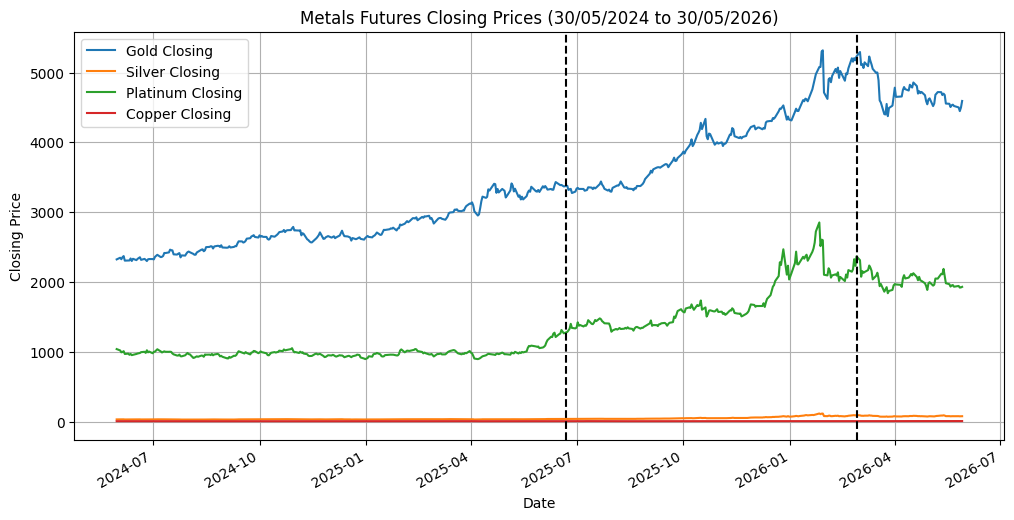

In [5]:
import matplotlib.pyplot as plt

# (7) Observe pre and post-crises. First Summer 2025 and Second, Feburary 2026 (Shutting of Hormous)
df.plot(figsize=(12,6))

plt.title("Metals Futures Closing Prices (30/05/2024 to 30/05/2026)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.axvline(x="2025-06-22", color="black", linestyle="--")
plt.axvline(x="2026-02-28", color="black", linestyle="--")
plt.show()

The Time series of the four commodities illustrates that long term trends persist and must be removed in order to achieve stationarity. As such, closing prices are often transformed into log returns for such purposes. Then meaningful analysis can begin. 

Another key insight from the graph above is that days of geo-political stress do no necessarily cause immediate appreciation of Gold or Platinum. Instead, lagged effects or missing (ommitted) variables can delay or reduce the channel of 'market panic' to percious metal appreciation.   

## **Citations**

Smales, L.A., 2014. News sentiment in the gold futures market. Journal of Banking & Finance, 49, pp.275-286.